In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

from imblearn.over_sampling import (
    SMOTE,
    ADASYN
)

from imblearn.under_sampling import (
    RandomUnderSampler
)

from imblearn.combine import (
    SMOTEENN
)

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "reddit_preprocessed.csv"
)

df.head()

,Unnamed: 0,clean_comment,category,word_count
0,0,family mormon never tried explain still stare ...,1,26
1,1,buddhism much lot compatible christianity espe...,1,140
2,2,seriously say thing first get complex explain ...,-1,46
3,3,learned want teach different focus goal not wr...,0,15
4,4,benefit may want read living buddha living chr...,1,68


In [4]:
X = df["clean_comment"]

y = df["category"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,1),
    max_features=10000
)

X_train_vec = vectorizer.fit_transform(
    X_train
)

X_test_vec = vectorizer.transform(
    X_test
)

In [7]:
def evaluate_model(
    X_train_data,
    y_train_data,
    class_weight=None
):

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        class_weight=class_weight
    )

    model.fit(
        X_train_data,
        y_train_data
    )

    y_pred = model.predict(
        X_test_vec
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    return accuracy

In [8]:
baseline_acc = evaluate_model(
    X_train_vec,
    y_train
)

print(
    "Baseline:",
    baseline_acc
)

Baseline: 0.6470986984815619


Clss_weight - negtive
## **bold text**

In [9]:
class_weight_acc = evaluate_model(
    X_train_vec,
    y_train,
    class_weight="balanced"
)

print(
    "Class Weight:",
    class_weight_acc
)

Class Weight: 0.6842462039045553


# **SMOTE**

In [11]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_vec,
    y_train
)

smote_acc = evaluate_model(
    X_train_smote,y_train_smote

)
print(
    "SMOTE:",
    smote_acc
)

SMOTE: 0.6713665943600867


# **ADASYN**

In [13]:
adasyn = ADASYN(
    random_state=42
)


X_adasyn,y_adasyn = adasyn.fit_resample(
    X_train_vec,
    y_train
)

adasyn_acc = evaluate_model(
    X_adasyn,
    y_adasyn
)

print(
    "ADASYN:",
    adasyn_acc
)

ADASYN: 0.6407266811279827


In [14]:
rus =RandomUnderSampler(
    random_state=42
)

X_rus,y_rus = rus.fit_resample(X_train_vec,y_train)

rus_acc = evaluate_model(
    X_rus,
    y_rus
)

print(
    "Under Sampling:",
    rus_acc
)

Under Sampling: 0.6781453362255966


In [15]:
smoteenn= SMOTEENN(
    random_state=42
)
X_smoteenn,y_smoteenn = smoteenn.fit_resample(
    X_train_vec,
    y_train
)

In [16]:
smoteenn_acc = evaluate_model(
    X_smoteenn,
    y_smoteenn
)

print(
    "SMOTEENN:",
    smoteenn_acc
)

SMOTEENN: 0.425704989154013


In [18]:
results = pd.DataFrame({

    "Method":[
        "Baseline",
        "Class Weight",
        "SMOTE",
        "ADASYN",
        "Under Sampling",
        "SMOTEENN"
    ],

    "Accuracy":[
        baseline_acc,
        class_weight_acc,
        smote_acc,
        adasyn_acc,
        rus_acc,
        smoteenn_acc
    ]
})

results

,Method,Accuracy
0,Baseline,0.647099
1,Class Weight,0.684246
2,SMOTE,0.671367
3,ADASYN,0.640727
4,Under Sampling,0.678145
5,SMOTEENN,0.425705


In [19]:
results.sort_values(
    by="Accuracy",
    ascending= False
)

,Method,Accuracy
1,Class Weight,0.684246
4,Under Sampling,0.678145
2,SMOTE,0.671367
0,Baseline,0.647099
3,ADASYN,0.640727
5,SMOTEENN,0.425705


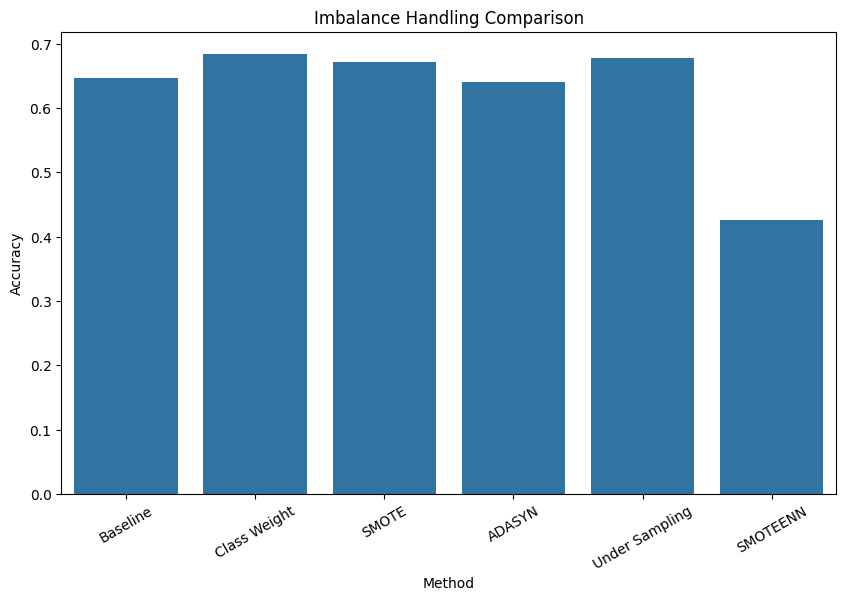

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Method",
    y="Accuracy"
)

plt.xticks(rotation=30)

plt.title(
    "Imbalance Handling Comparison"
)

plt.show()

In [21]:
best_method = results.loc[
    results["Accuracy"].idxmax()
]

best_method

,1
Method,Class Weight
Accuracy,0.684246


In [22]:
results.to_csv(
    "imbalance_results.csv",
    index=False
)

In [23]:
from collections import Counter

print(Counter(y_train))
print(Counter(y_smoteenn))

Counter({1: 12663, 0: 10219, -1: 6620})
Counter({-1: 7588, 0: 5806, 1: 652})


In [24]:
print(X_train_vec.shape)
print(X_smoteenn.shape)

(29502, 10000)
(14046, 10000)
